# Uniformization of CTMC

To get the distribution at time $t$:

$$p(t) = \sum_{n=0}^{\infty} e^{-\lambda t} \frac{(\lambda t)^n}{n!} P^n p(0)$$

Weight $P^n$ (n applications of the DTMC) by Poisson $(\lambda t)$ probabilities.

The circuit can be viewed as uniformized from a CTMC where each gate with probability $p$ has rate $r = p \cdot \lambda$.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from torx import DiscretePCircuit, PNOT, StateVectorSimulator

In [2]:
@eqx.filter_jit
def uniformization_density(circuit, x, t, rate=1.0, max_steps=10):
    sim = StateVectorSimulator()
    lambda_t = rate * t

    # Poisson probabilities
    ns = jnp.arange(max_steps)
    log_poisson = (
        ns * jnp.log(lambda_t + 1e-10) - lambda_t - jax.scipy.special.gammaln(ns + 1)
    )
    poisson_probs = jnp.exp(log_poisson)

    def scan_fn(state, poisson_prob):
        contribution = poisson_prob * state
        next_state = sim.density(circuit, state)
        return next_state, contribution

    _, contributions = jax.lax.scan(scan_fn, x, poisson_probs)
    return jnp.sum(contributions, axis=0)

## Single Bit Flip

A PNOT with probability $p$ gives a symmetric two-state CTMC. Analytical solution:

$ P(1, t) = \frac{1}{2}(1 - e^{-2rt}) $

where $r = p \cdot \lambda$

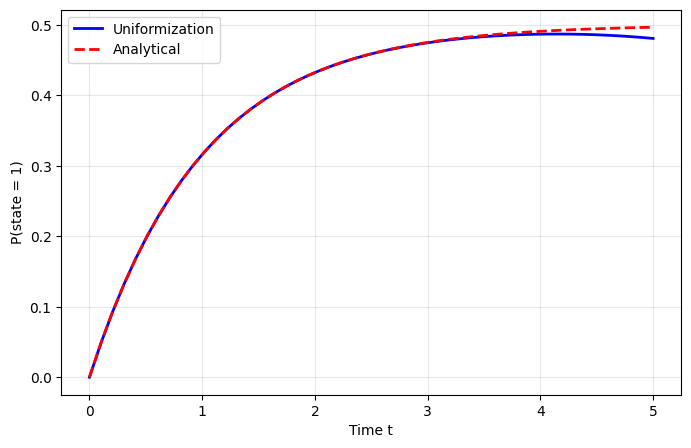

In [3]:
circuit = DiscretePCircuit([PNOT(jnp.array(0.0), 0)])  # p = 0.5
x0 = jnp.array([1.0, 0.0])

evolve = jax.jit(lambda x, t, rate: uniformization_density(circuit, x, t, rate))

times = jnp.linspace(0, 5, 50)
probs = jnp.array([evolve(x0, t, 1.0)[1] for t in times])
analytical = 0.5 * (1 - jnp.exp(-2 * 0.5 * 1.0 * times))

plt.figure(figsize=(8, 5))
plt.plot(times, probs, "b-", lw=2, label="Uniformization")
plt.plot(times, analytical, "r--", lw=2, label="Analytical")
plt.xlabel("Time t")
plt.ylabel("P(state = 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Truncation Error

The Poisson sum is infinite, but we truncate at $N$ terms (`max_steps`). The error is the probability mass in the tail:

$$\text{error} \approx \sum_{n=N}^{\infty} \frac{e^{-\lambda t} (\lambda t)^n}{n!} = 1 - \text{CDF}_{\text{Poisson}}(N-1; \lambda t)$$

For larger $\lambda t$, the Poisson distribution shifts right, requiring more terms.

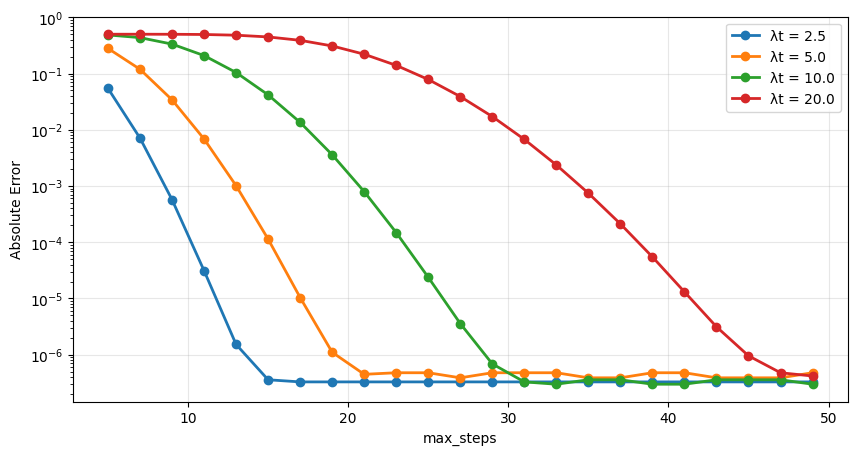

In [4]:
t_fixed = 5.0
p = 0.5

max_steps_range = jnp.arange(5, 50, 2)

plt.figure(figsize=(10, 5))

for rate in [0.5, 1.0, 2.0, 4.0]:
    exact = 0.5 * (1 - jnp.exp(-2 * p * rate * t_fixed))

    errors = []
    for ms in max_steps_range:
        result = uniformization_density(
            circuit, x0, t_fixed, rate=rate, max_steps=int(ms)
        )
        errors.append(float(jnp.abs(result[1] - exact)))
    plt.semilogy(
        max_steps_range, errors, "o-", lw=2, label=f"λt = {rate * t_fixed:.1f}"
    )

plt.xlabel("max_steps")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()